# Système de recommandation de livres — Exploration & Préparation

## Objectifs
1. **Recommandations personnalisées** : recommander des livres à chaque utilisateur à partir des notes (approche collaborative **Item-Based KNN**).
2. **Livres similaires** : identifier des livres proches à partir du contenu textuel (approche **TF-IDF + similarité cosinus**).

## Remarque importante sur les données
- Le fichier de notes (`collaborative_books_df.csv`) couvre **898 livres**.
- Le fichier de métadonnées (`collaborative_book_metadata.csv`) ne couvre que **96 livres**.
➡️ On prépare donc **deux pipelines** (collaboratif / contenu) et on relie seulement via `book_id_mapping` si nécessaire.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

from IPython.display import display

### 0 — Paramètres (modifiable)

- `min_user_ratings` : seuil minimal de notes par utilisateur (filtrage).
- `min_book_ratings` : seuil minimal de notes par livre (filtrage).
- `tfidf_min_df` : paramètre TF‑IDF `min_df`.
- `tfidf_stop_words` : stop words pour TF‑IDF.

Les valeurs ci‑dessous sont des choix raisonnables pour commencer et peuvent être ajustées.

```python
min_user_ratings = 2
min_book_ratings = 5
tfidf_min_df = 1
tfidf_stop_words = 'english'
```


## 1) Chargement des données
On charge les 5 fichiers CSV fournis :
- `rating_df` : table des notes (base principale pour la reco personnalisée)
- `metadata` : métadonnées texte (base pour TF-IDF)
- `book_titles`, `book_id_map`, `user_id_map` : fichiers d’appoint (titres / correspondances)

In [88]:
book_id_map = pd.read_csv('../data/book_id_map.csv')
book_titles = pd.read_csv('../data/book_titles.csv')
metadata = pd.read_csv('../data/collaborative_book_metadata.csv')
rating_df = pd.read_csv('../data/collaborative_books_df.csv')
user_id_map = pd.read_csv('../data/user_id_map.csv')

## 2) Exploration initiale
On crée une fonction `overview_plus()` pour voir :
- dimensions,
- aperçu des lignes,
- types de colonnes,
- valeurs manquantes,
- doublons.

In [90]:
def overview_plus(df, name, n=5):
    print("\n" + "="*60)
    print("{}  ->  {} lignes, {} colonnes".format(name, df.shape[0], df.shape[1]))
    print("="*60)
    
    display(df.head(n))
    
    print("\n--- info() ---")
    df.info()
    
    print("\n--- Valeurs manquantes (top 10) ---")
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    if miss.empty:
        print("Aucune valeur manquante OK")
    else:
        print(miss)
    
    print("\n--- Doublons (lignes) ---")
    print(df.duplicated().sum())

In [91]:
overview_plus(book_id_map, "book_id_map")
overview_plus(book_titles, "book_titles")
overview_plus(metadata, "metadata (brute)")
overview_plus(rating_df, "rating_df (brut)")
overview_plus(user_id_map, "user_id_map")


book_id_map  ->  2360650 lignes, 2 colonnes


,book_id_csv,book_id
0,0,34684622
1,1,34536488
2,2,34017076
3,3,71730
4,4,30422361



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2360650 entries, 0 to 2360649
Data columns (total 2 columns):
 #   Column       Dtype
---  ------       -----
 0   book_id_csv  int64
 1   book_id      int64
dtypes: int64(2)
memory usage: 36.0 MB

--- Valeurs manquantes (top 10) ---
Aucune valeur manquante OK

--- Doublons (lignes) ---
0

book_titles  ->  1447341 lignes, 2 colonnes


,title,book_id
0,The Unschooled Wizard Sun Wolf and Starhawk 12,7327624
1,Best Friends Forever,6066819
2,The Aeneid for Boys and Girls,287141
3,Alls Fairy in Love and War Avalon Web of Magic 8,6066812
4,The Devils Notebook,287149



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447341 entries, 0 to 1447340
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   title    1437948 non-null  object
 1   book_id  1447341 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 22.1+ MB

--- Valeurs manquantes (top 10) ---
title    9393
dtype: int64

--- Doublons (lignes) ---
0

metadata (brute)  ->  96 lignes, 11 colonnes


...


--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       96 non-null     int64 
 1   book_id          96 non-null     int64 
 2   title            96 non-null     object
 3   image_url        96 non-null     object
 4   url              96 non-null     object
 5   num_pages        96 non-null     int64 
 6   ratings_count    96 non-null     int64 
 7   description      96 non-null     object
 8   genre            96 non-null     object
 9   name             96 non-null     object
 10  book_id_mapping  96 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 8.4+ KB

--- Valeurs manquantes (top 10) ---
Aucune valeur manquante OK

--- Doublons (lignes) ---
0

rating_df (brut)  ->  196296 lignes, 7 colonnes


,Unnamed: 0,title,book_id,user_id_mapping,book_id_mapping,Predicted Rating,Actual Rating
0,0,I Am the Messenger,19057,1537,299,4.5,5
1,1,I Am the Messenger,19057,23039,299,4.9,3
2,2,I Am the Messenger,19057,39096,299,3.9,3
3,3,I Am the Messenger,19057,14631,299,4.7,4
4,4,I Am the Messenger,19057,32816,299,4.3,5



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196296 entries, 0 to 196295
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        196296 non-null  int64  
 1   title             196296 non-null  object 
 2   book_id           196296 non-null  int64  
 3   user_id_mapping   196296 non-null  int64  
 4   book_id_mapping   196296 non-null  int64  
 5   Predicted Rating  196296 non-null  float64
 6   Actual Rating     196296 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 10.5+ MB

--- Valeurs manquantes (top 10) ---
Aucune valeur manquante OK

--- Doublons (lignes) ---
0

user_id_map  ->  876145 lignes, 2 colonnes


,user_id_csv,user_id
0,0,8842281e1d1347389f2ab93d60773d4d
1,1,72fb0d0087d28c832f15776b0d936598
2,2,ab2923b738ea3082f5f3efcbbfacb218
3,3,d986f354a045ffb91234e4af4d1b12fd
4,4,7504b2aee1ecb5b2872d3da381c6c91e



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876145 entries, 0 to 876144
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   user_id_csv  876145 non-null  int64 
 1   user_id      876145 non-null  object
dtypes: int64(1), object(1)
memory usage: 13.4+ MB

--- Valeurs manquantes (top 10) ---
Aucune valeur manquante OK

--- Doublons (lignes) ---
0


### Résultats & interprétation (attendus d’après tes sorties)
- `rating_df` : ~196k lignes, pas de valeurs manquantes, pas de doublons → très bon pour la reco.
- `metadata` : 96 lignes, texte complet → bon pour TF-IDF mais couverture faible.
- `book_titles` : titres manquants (~9393) → on nettoiera si besoin d’affichage.
- `book_id_map` et `user_id_map` : tables de correspondance propres.

## 3) Nettoyage des données
On nettoie seulement ce qui est utile aux deux objectifs :
- `rating_df` : suppression colonne index + renommage des colonnes de notes
- `metadata` : suppression colonnes inutiles (urls/images)
- `book_titles` : suppression des titres vides (utile surtout pour affichage)

In [94]:
# rating_df : supprimer index inutile + renommer colonnes
if "Unnamed: 0" in rating_df.columns:
    rating_df = rating_df.drop(columns=["Unnamed: 0"])

rating_df = rating_df.rename(columns={
    "Predicted Rating": "pred_rating",
    "Actual Rating": "rating"
})

rating_df["rating"] = rating_df["rating"].astype(float)

print("Doublons rating_df:", rating_df.duplicated().sum())
print("Valeurs manquantes rating_df:", rating_df.isna().sum().sum())
rating_df.head()

Doublons rating_df: 0
Valeurs manquantes rating_df: 0


,title,book_id,user_id_mapping,book_id_mapping,pred_rating,rating
0,I Am the Messenger,19057,1537,299,4.5,5.0
1,I Am the Messenger,19057,23039,299,4.9,3.0
2,I Am the Messenger,19057,39096,299,3.9,3.0
3,I Am the Messenger,19057,14631,299,4.7,4.0
4,I Am the Messenger,19057,32816,299,4.3,5.0


### Interprétation
- `rating_df` est maintenant propre : colonnes bien nommées, `rating` en float.
- Pas de doublons → chaque évaluation est unique.

In [96]:
# metadata : supprimer colonnes inutiles
cols_to_drop = [c for c in ["Unnamed: 0", "image_url", "url", "name"] if c in metadata.columns]
metadata = metadata.drop(columns=cols_to_drop)

# nettoyer texte
for col in ["title", "description", "genre"]:
    metadata[col] = metadata[col].astype(str).str.strip()

print(metadata.shape)
metadata.head()

(96, 7)


,book_id,title,num_pages,ratings_count,description,genre,book_id_mapping
0,5899779,Pride and Prejudice and Zombies Pride and Prej...,320,105537,The New York Times Best Seller is now a major ...,"['fantasy, paranormal', 'romance', 'fiction', ...",808
1,872333,Blue Bloods Blue Bloods 1,302,117633,"When the Mayflower set sail in 1620, it carrie...","['young-adult', 'fantasy, paranormal', 'romanc...",217
2,15507958,Me Before You Me Before You 1,369,609327,Louisa Clark is an ordinary young woman living...,"['romance', 'fiction']",385
3,66559,Sharp Objects,254,208394,"Fresh from a brief stay at a psych hospital, r...","['mystery, thriller, crime', 'fiction']",192
4,7235533,The Way of Kings The Stormlight Archive 1,1007,151473,"Speak again the ancient oaths,\nLife before de...","['fantasy, paranormal', 'fiction']",873


In [97]:
book_titles = book_titles.dropna(subset=["title"])
book_titles["title"] = book_titles["title"].str.strip()
book_titles = book_titles[book_titles["title"] != ""]

book_titles.isna().sum()

title      0
book_id    0
dtype: int64

In [98]:
ratings = rating_df[["user_id_mapping", "book_id_mapping", "rating"]].copy()
print(ratings.shape)
ratings.head()

(196296, 3)


,user_id_mapping,book_id_mapping,rating
0,1537,299,5.0
1,23039,299,3.0
2,39096,299,3.0
3,14631,299,4.0
4,32816,299,5.0


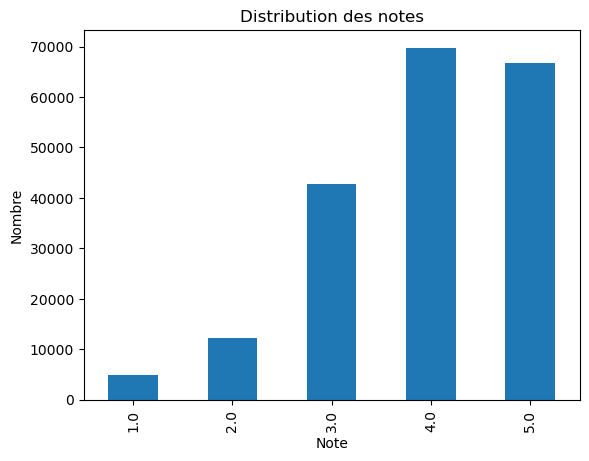

In [99]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution des notes")
plt.xlabel("Note")
plt.ylabel("Nombre")
plt.show()

Notes par user -> mean: 2.93 | median: 2.0 | max: 22
Notes par book -> mean: 218.59 | median: 165.5 | max: 1296


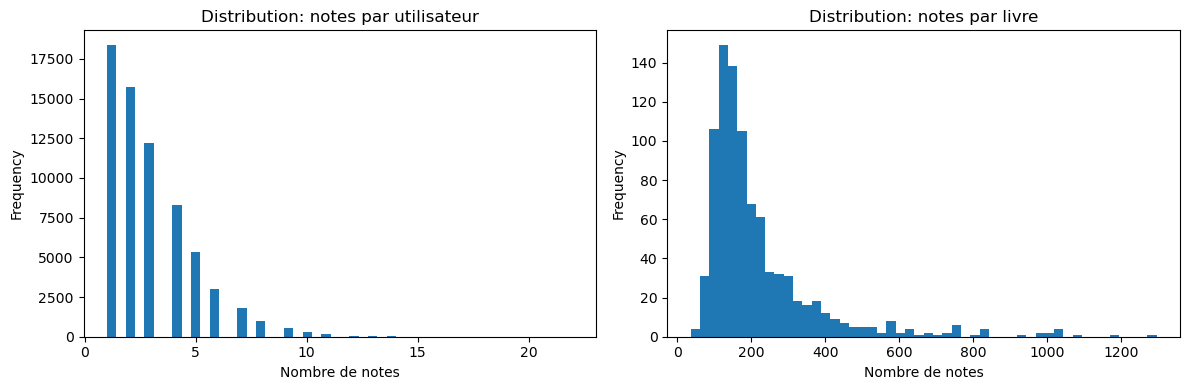

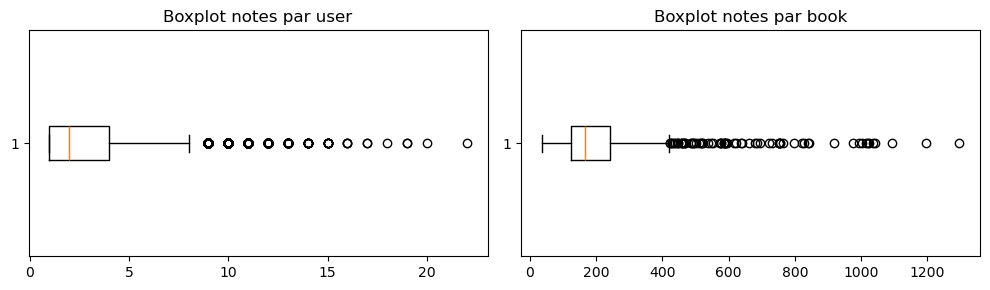

Users: 66909 | Books: 898 | Ratings: 196296
Sparsité approx: 99.67 %


In [100]:
# Statistiques et visualisations univariées pour les counts
notes_user = ratings.groupby("user_id_mapping").size()
notes_book = ratings.groupby("book_id_mapping").size()

print("Notes par user -> mean:", round(notes_user.mean(),2), "| median:", notes_user.median(), "| max:", notes_user.max())
print("Notes par book -> mean:", round(notes_book.mean(),2), "| median:", notes_book.median(), "| max:", notes_book.max())

# Histogrammes
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
notes_user.plot(kind='hist', bins=50)
plt.title('Distribution: notes par utilisateur')
plt.xlabel('Nombre de notes')

plt.subplot(1,2,2)
notes_book.plot(kind='hist', bins=50)
plt.title('Distribution: notes par livre')
plt.xlabel('Nombre de notes')
plt.tight_layout()
plt.show()

# Boxplots (évite l'influence des outliers visuellement)
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.boxplot(notes_user, vert=False)
plt.title('Boxplot notes par user')
plt.subplot(1,2,2)
plt.boxplot(notes_book, vert=False)
plt.title('Boxplot notes par book')
plt.tight_layout()
plt.show()

# Sparsité
n_users = ratings["user_id_mapping"].nunique()
n_books = ratings["book_id_mapping"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_books))
print("Users:", n_users, "| Books:", n_books, "| Ratings:", n_ratings)
print("Sparsité approx:", round(sparsity*100, 2), "%")


### Interprétation détaillée

- Distribution des notes : on observe un biais vers les notes élevées (souvent 4–5), ce qui est fréquent dans les datasets publics où les utilisateurs évaluent surtout ce qu'ils aiment.
- Nombre de notes par utilisateur/livre : la médiane faible indique que beaucoup d'utilisateurs ont peu d'interactions (cold‑start). Les boxplots montrent l'existence d'outliers (utilisateurs très actifs).
- Sparsité ≈ 99.6% : la matrice user–item est très creuse → choix d'une méthode item‑based est justifié, car elle exploite les similarités entre items et résiste mieux au très faible nombre d'interactions par utilisateur.

Conséquence pratique : privilégier un modèle item‑based pour la recommandation personnalisée, et utiliser TF‑IDF pour proposer des alternatives basées sur le contenu lorsque les utilisateurs ont peu d'historique.


## 5) Préparation Objectif 1 : Reco personnalisée (Item-Based)
On filtre pour réduire le cold-start extrême :
- utilisateurs avec ≥ 2 notes
- livres avec ≥ 5 notes

In [103]:
user_counts = ratings["user_id_mapping"].value_counts()
book_counts = ratings["book_id_mapping"].value_counts()

min_user_ratings = 2
min_book_ratings = 5

ratings_filt = ratings[
    ratings["user_id_mapping"].isin(user_counts[user_counts >= min_user_ratings].index) &
    ratings["book_id_mapping"].isin(book_counts[book_counts >= min_book_ratings].index)
].copy()

print("Avant:", ratings.shape)
print("Après:", ratings_filt.shape)
print("Users:", ratings_filt["user_id_mapping"].nunique())
print("Books:", ratings_filt["book_id_mapping"].nunique())

Avant: (196296, 3)
Après: (177916, 3)
Users: 48529
Books: 898


(177916, 4)
Titres manquants: 0


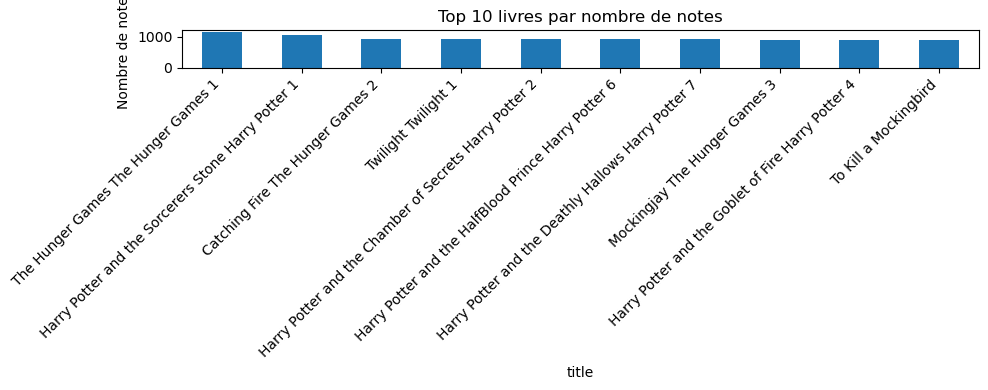

In [104]:
book_lookup = rating_df.groupby("book_id_mapping")["title"].first().reset_index()
ratings_with_title = ratings_filt.merge(book_lookup, on="book_id_mapping", how="left")

print(ratings_with_title.shape)
print("Titres manquants:", ratings_with_title["title"].isna().sum())
ratings_with_title.head()

# Top 10 livres par nombre de notes (visualisation)
top_books = ratings_with_title.groupby("title").size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
top_books.plot(kind='bar')
plt.title('Top 10 livres par nombre de notes')
plt.ylabel('Nombre de notes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [105]:
n_users2 = ratings_with_title["user_id_mapping"].nunique()
n_books2 = ratings_with_title["book_id_mapping"].nunique()
n_ratings2 = len(ratings_with_title)

sparsity2 = 1 - (n_ratings2 / (n_users2 * n_books2))
print("Sparsité après filtre:", round(sparsity2*100, 2), "%")

Sparsité après filtre: 99.59 %


### Interprétation (basée sur tes résultats)
- Après filtre : ~177 916 notes, 48 529 users, 898 livres.
- Sparsité ≈ 99.59% → encore très creux mais plus stable.
➡️ On construit une matrice **item-user sparse** puis une similarité **item-item**.

In [107]:
unique_users = ratings_filt["user_id_mapping"].unique()
unique_books = ratings_filt["book_id_mapping"].unique()

user_to_idx = {u:i for i,u in enumerate(unique_users)}
book_to_idx = {b:i for i,b in enumerate(unique_books)}

rows = ratings_filt["book_id_mapping"].map(book_to_idx).values
cols = ratings_filt["user_id_mapping"].map(user_to_idx).values
vals = ratings_filt["rating"].values

item_user_sparse = csr_matrix((vals, (rows, cols)), shape=(len(unique_books), len(unique_users)))

print("Item-User shape:", item_user_sparse.shape)
print("Non-zeros:", item_user_sparse.nnz)

Item-User shape: (898, 48529)
Non-zeros: 177916


In [108]:
item_item_sim = cosine_similarity(item_user_sparse)
print("Item-Item similarity shape:", item_item_sim.shape)
print("Exemple ligne 0 (5 premières valeurs):", item_item_sim[0][:5])

Item-Item similarity shape: (898, 898)
Exemple ligne 0 (5 premières valeurs): [1. 0. 0. 0. 0.]


In [109]:
def recommend_for_user(user_id, top_n=5):
    if user_id not in user_to_idx:
        return "User inconnu dans le dataset filtré."

    u_idx = user_to_idx[user_id]
    user_ratings = item_user_sparse[:, u_idx].toarray().ravel()

    rated_items = np.where(user_ratings > 0)[0]
    scores = np.zeros(item_user_sparse.shape[0])

    for b in rated_items:
        scores += item_item_sim[b] * user_ratings[b]

    scores[rated_items] = -1  # ne pas recommander déjà noté

    top_idx = np.argsort(scores)[::-1][:top_n]
    recs = []
    for idx in top_idx:
        book_id = unique_books[idx]
        title = book_lookup[book_lookup["book_id_mapping"] == book_id]["title"].iloc[0]
        recs.append((book_id, title, scores[idx]))

    return recs

example_user = unique_users[0]
recommend_for_user(example_user, top_n=5)

[(53, 'Delirium Delirium 1', 0.5973190827634259),
 (356, 'A Darker Shade of Magic Shades of Magic 1', 0.48977929411240695),
 (27,
  'The Sea of Monsters Percy Jackson and the Olympians 2',
  0.4604007299276725),
 (615, 'Fire Graceling Realm 2', 0.44998000556489565),
 (58, 'The Hunger Games The Hunger Games 1', 0.4336552040344312)]

### Interprétation
La recommandation item-based :
- prend les livres déjà notés par l’utilisateur,
- cherche les livres similaires (item-item),
- calcule un score pondéré par la note,
- recommande les meilleurs livres non encore notés.

## 6) Préparation Objectif 2 : Livres similaires (TF-IDF)
On utilise `metadata` (96 livres).  
On vérifie le recouvrement avec les livres du dataset de notes.

In [112]:
common = set(rating_df["book_id_mapping"]).intersection(set(metadata["book_id_mapping"]))
print("Livres communs:", len(common))
print("Livres uniques rating_df:", rating_df["book_id_mapping"].nunique())
print("Livres uniques metadata:", metadata["book_id_mapping"].nunique())

Livres communs: 95
Livres uniques rating_df: 898
Livres uniques metadata: 96


### Interprétation (basée sur tes résultats)
- Livres communs ≈ 95
- `metadata` est petit → TF-IDF sera limité à 96 livres.

Min: 291 | Median: 879.5 | Max: 2342
Textes vides: 0


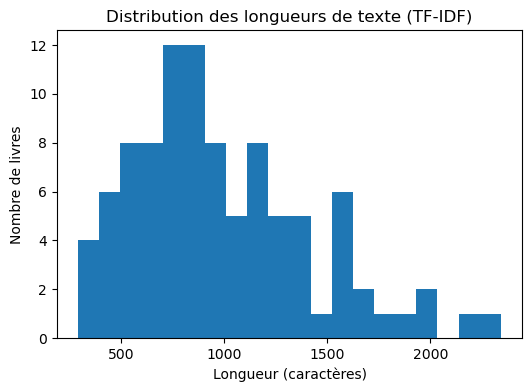

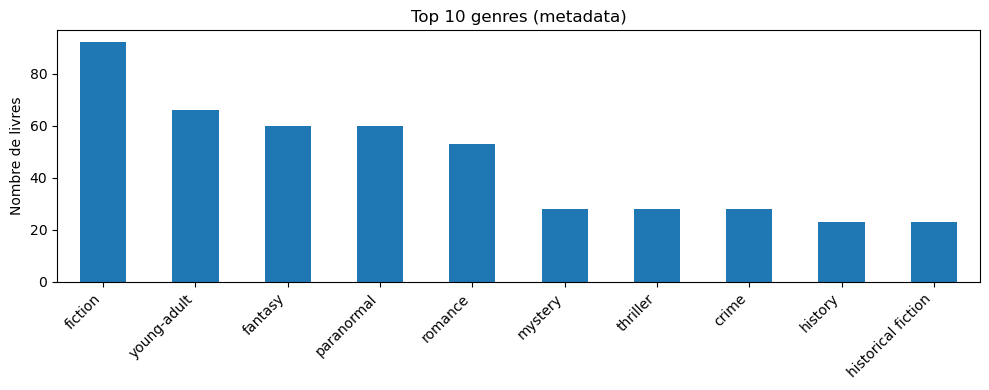

In [114]:
tfidf_books = metadata.copy()

# Nettoyage et préparation texte

tfidf_books["genre_clean"] = (
    tfidf_books["genre"].astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace(",", " ", regex=False)
    .str.lower()
    .str.strip()
)

tfidf_books["text"] = (
    tfidf_books["title"].astype(str).str.lower().str.strip() + " " +
    tfidf_books["genre_clean"].fillna("") + " " +
    tfidf_books["description"].astype(str).str.lower().str.strip()
).str.strip()

# longueurs de texte

tfidf_books["text_len"] = tfidf_books["text"].str.len()

print("Min:", tfidf_books["text_len"].min(),
      "| Median:", tfidf_books["text_len"].median(),
      "| Max:", tfidf_books["text_len"].max())
print("Textes vides:", (tfidf_books["text_len"] == 0).sum())

# Histogramme des longueurs de texte
plt.figure(figsize=(6,4))
plt.hist(tfidf_books['text_len'].dropna(), bins=20)
plt.title('Distribution des longueurs de texte (TF-IDF)')
plt.xlabel('Longueur (caractères)')
plt.ylabel('Nombre de livres')
plt.show()

# Répartition des genres (approx.)
from collections import Counter
genres = tfidf_books['genre'].dropna().astype(str)
counter = Counter()
for g in genres:
    for part in g.strip('[]').replace("'","").split(','):
        p = part.strip().lower()
        if p:
            counter[p] += 1

genre_counts = pd.Series(counter).sort_values(ascending=False)
plt.figure(figsize=(10,4))
genre_counts.head(10).plot(kind='bar')
plt.title('Top 10 genres (metadata)')
plt.ylabel('Nombre de livres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [115]:
tfidf_books

,book_id,title,num_pages,ratings_count,description,genre,book_id_mapping,genre_clean,text,text_len
0,5899779,Pride and Prejudice and Zombies Pride and Prej...,320,105537,The New York Times Best Seller is now a major ...,"['fantasy, paranormal', 'romance', 'fiction', ...",808,fantasy paranormal romance fiction history...,pride and prejudice and zombies pride and prej...,1386
1,872333,Blue Bloods Blue Bloods 1,302,117633,"When the Mayflower set sail in 1620, it carrie...","['young-adult', 'fantasy, paranormal', 'romanc...",217,young-adult fantasy paranormal romance fic...,blue bloods blue bloods 1 young-adult fantasy...,1395
2,15507958,Me Before You Me Before You 1,369,609327,Louisa Clark is an ordinary young woman living...,"['romance', 'fiction']",385,romance fiction,me before you me before you 1 romance fiction...,965
3,66559,Sharp Objects,254,208394,"Fresh from a brief stay at a psych hospital, r...","['mystery, thriller, crime', 'fiction']",192,mystery thriller crime fiction,sharp objects mystery thriller crime fictio...,695
4,7235533,The Way of Kings The Stormlight Archive 1,1007,151473,"Speak again the ancient oaths,\nLife before de...","['fantasy, paranormal', 'fiction']",873,fantasy paranormal fiction,the way of kings the stormlight archive 1 fant...,1215
...,...,...,...,...,...,...,...,...,...,...
91,10600242,How to Be a Woman,312,72029,Though they have the vote and the Pill and hav...,"['non-fiction', 'history, historical fiction, ...",356,non-fiction history historical fiction biog...,how to be a woman non-fiction history histor...,600
92,9516,Persepolis The Story of a Childhood Persepolis 1,153,119470,"A New York TimesNotable Book\nA Time Magazine""...","['comics, graphic', 'non-fiction', 'history, h...",708,comics graphic non-fiction history histori...,persepolis the story of a childhood persepolis...,1565
93,307791,The City of Ember Book of Ember 1,270,202775,"Many hundreds of years ago, the city of Ember ...","['young-adult', 'fantasy, paranormal', 'fictio...",175,young-adult fantasy paranormal fiction chi...,the city of ember book of ember 1 young-adult ...,700
94,37442,Wicked The Life and Times of the Wicked Witch ...,409,508863,When Dorothy triumphed over the Wicked Witch o...,"['fantasy, paranormal', 'fiction', 'young-adul...",374,fantasy paranormal fiction young-adult rom...,wicked the life and times of the wicked witch ...,1337


In [116]:
vectorizer = TfidfVectorizer(stop_words="english")
X_tfidf = vectorizer.fit_transform(tfidf_books["text"])

print("TF-IDF shape:", X_tfidf.shape)
print("Vocabulaire:", len(vectorizer.get_feature_names_out()))

cos_sim = cosine_similarity(X_tfidf)
print("Cosine similarity shape:", cos_sim.shape)

TF-IDF shape: (96, 3746)
Vocabulaire: 3746
Cosine similarity shape: (96, 96)


In [117]:
titles = tfidf_books["title"].tolist()

def top_similar_books_content(book_index, top_n=5):
    sims = cos_sim[book_index]
    idx = np.argsort(sims)[::-1]
    idx = [i for i in idx if i != book_index][:top_n]
    return [(titles[i], sims[i]) for i in idx]

print("Livre référence:", titles[0])
top_similar_books_content(0, top_n=5)

Livre référence: Pride and Prejudice and Zombies Pride and Prejudice and Zombies 1


[('Saga Vol 2 Saga 2', 0.050850679957732264),
 ('The Hunt for Red October Jack Ryan Universe 4', 0.050585545607935385),
 ('Something Borrowed Darcy Rachel 1', 0.046680877589438084),
 ('Freakonomics A Rogue Economist Explores the Hidden Side of Everything Freakonomics 1',
  0.040843962670445176),
 ('Maus I A Survivors Tale My Father Bleeds History Maus 1',
  0.03818512608578456)]

### Interprétation
- TF-IDF transforme chaque livre en vecteur de termes.
- La similarité cosinus compare ces vecteurs.
- Les scores peuvent être faibles (corpus petit + descriptions variées), mais on obtient tout de même une liste de livres proches.

## Conclusion
- Le dataset de notes est très clairsemé (>99% de sparsité), donc l’approche **Item-Based KNN** est adaptée.
- Le dataset de métadonnées est petit (96 livres), mais permet de calculer une similarité **TF-IDF** exploitable.
- Les deux objectifs sont atteints :
  1) préparation + démo d’une recommandation personnalisée,
  2) calcul de livres similaires via contenu.

In [ ]:
# similiraty cosine


In [142]:
print("Livre référence:", titles[0])

Livre référence: Pride and Prejudice and Zombies Pride and Prejudice and Zombies 1
